In [1]:
import pandas as pd
import numpy as np
import os, sys, importlib, time
from tqdm import tqdm
tqdm.pandas()
sys.path.append(os.path.abspath(".."))

In [ ]:
df=pd.read_csv("../sandbox\data/20251201-ProductionScientifiqueIRG-__-202512_2734art.csv")

#用25年之前的数据：
df_before_2024=df[df["submittedDate_s"]<="2024-12-31 23:59:59"]#before2024
df_before_2024_hasaxe=df_before_2024[df_before_2024['axe'].notna()]#has axe
print(len(df), len(df_before_2024), len(df_before_2024_hasaxe))

print(df_before_2024_hasaxe.axe.value_counts(dropna=False))
print(df_before_2024_hasaxe.docType_s.value_counts(dropna=False))


2734 2486 2021
axe
3       1050
1        653
2        251
4         46
2; 3       8
1; 3       7
1; 2       4
3; 1       1
3; 4       1
Name: count, dtype: int64
docType_s
COMM    931
ART     692
COUV    303
OUV      95
Name: count, dtype: int64


axe_list
3      1067
1       665
nan     465
2       263
4        47
Name: count, dtype: int64


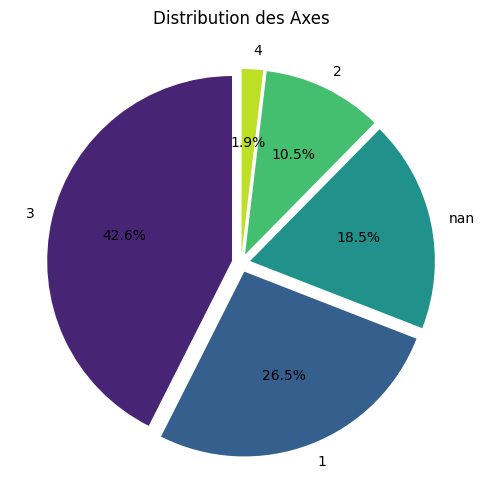

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 拆分多标签
df_split = df_before_2024.copy()
df_split['axe_list'] = df_split['axe'].fillna("nan").str.split('; ')

# 展平
all_axes = df_split['axe_list'].explode()

# 统计每个 axe
axe_counts = all_axes.value_counts()
print(axe_counts)


# 使用 viridis 调色板
cmap = plt.cm.viridis
sizes = axe_counts.values
colors = cmap(np.linspace(0.1, 0.9, len(sizes)))

plt.figure(figsize=(6,6))
plt.pie(
    axe_counts,
    labels=axe_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.05]*len(axe_counts)  # 可选，微微分离每块
)
plt.title("Distribution des Axes")
plt.savefig("../sandbox/figs/distribution_axes_before2024.jpg", dpi=300)
plt.show()


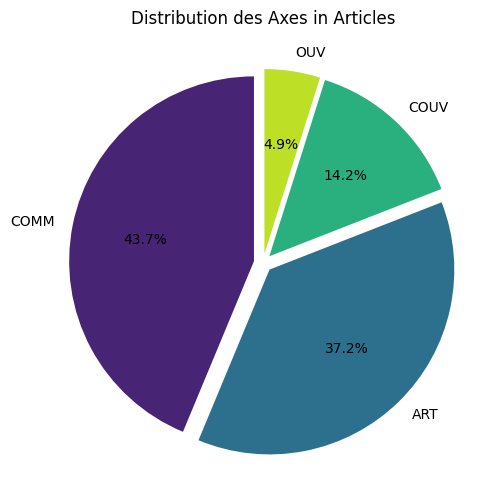

In [12]:
doctype_counts=df_before_2024.docType_s.value_counts()

# 使用 viridis 调色板
cmap = plt.cm.viridis
sizes = doctype_counts.values
colors = cmap(np.linspace(0.1, 0.9, len(sizes)))

plt.figure(figsize=(6,6))
plt.pie(
    doctype_counts,
    labels=doctype_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.05]*len(doctype_counts)  # 可选，微微分离每块
)
plt.title("Distribution des Axes in Articles")
plt.show()


## embeddings 

In [ ]:
df_emb=pd.read_parquet("../external_data\embeddings_all\df_before2024_3emb.parquet")

display(df_emb.head())

,halId_s,uri_s,docType_s,title_s,subTitle_s,authFullName_s,authIdHal_s,labStructName_s,author_primarystructure_s,collName_s,...,urlFulltextEsr_s,fnege_year,axes_vec,axe1,axe2,axe3,axe4,emb_title_s,emb_keyword_s,emb_abstract_s
253,hal-04836262,https://hal.science/hal-04836262v1,ART,Culture « fun et pro » au travail et liberté d...,None,Joan Le Goff; Brigitte Pereira,joan-le-goff; brigitte-pereira,Institut de Recherche en Gestion; Métis Lab EM...,1004418_Institut de Recherche en Gestion;15091...,Sciences de l'Homme et de la Société; École de...,...,NaN,2022,"[1, 0, 0, 0]",1,0,0,0,"[-0.067080185, -0.0033619883, -0.057862666, 0....","[-0.05938513, 0.015668642, -0.0027596208, -0.0...","[-0.06698241, 0.012503117, -0.031837963, 0.012..."
254,hal-04834794,https://hal.science/hal-04834794v1,ART,Using Tabletop Role-Playing Games to Teach Eng...,None,Patricia Fournier-Noel; Philippe Lépinard; Odi...,patricia-fournier-noel; philippe-lepinard,"Institut des Mondes Anglophone, Germanique et ...","106107_PRISMES - Langues, Textes, Arts et Cult...",Sciences de l'Homme et de la Société; Biblioth...,...,NaN,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.05644952, -0.015046884, -0.0052401857, -0....","[-0.0025393004, -0.017068807, -0.007008952, 0....","[-0.042379122, -0.008839208, 0.021449, -0.0087..."
255,hal-04833698,https://hal.science/hal-04833698v1,ART,Des wargames au wargaming en école de manageme...,None,Philippe Lépinard,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Biblioth...,...,NaN,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.036749814, 0.0021412692, -0.019894047, -0....","[-0.024955845, 0.014600282, -0.035181217, 0.00...","[-0.04794348, 0.01304505, -0.021989746, -0.007..."
259,hal-04825843,https://hal.u-pec.fr/hal-04825843v1,COMM,Preserving the dignity of the identity of others,None,Éric Gautier; Patrick Mathieu; Richard Major; ...,eric-gautier,Institut de Recherche en Gestion; Laboratoire ...,1004418_Institut de Recherche en Gestion;19805...,Sciences de l'Homme et de la Société; Aix Mars...,...,NaN,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.020850625, 0.0036672787, -0.029843781, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
260,hal-04825838,https://hal.u-pec.fr/hal-04825838v1,COMM,The Impact of the Mentor’s Values on the Mente...,None,Hayoung Park; Catherine Voynnet Fourboul; Eric...,catherine-voynnet-fourboul; eric-gautier,Laboratoire de recherche en sciences de gestio...,no primary structure found;1096497_Laboratoire...,Sciences de l'Homme et de la Société; Institut...,...,NaN,2022,"[0, 0, 1, 0]",0,0,1,0,"[0.0033030745, -0.01817476, -0.0034594173, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [27]:
import umap
import numpy as np

# 示例：只用 abstrac
X_abs = np.stack(df_emb["emb_abstract_s"].values)

# 范数 > 0 的才保留
mask_nonzero = np.linalg.norm(X_abs, axis=1) > 0

X_abs_nz = X_abs[mask_nonzero]
df_nz = df_emb.loc[mask_nonzero].reset_index(drop=True)


reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)
X_2d = reducer.fit_transform(X_abs_nz)


d:\miniconda3\envs\irg_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [31]:
df_nz["axe"].values

array(['1', '3', '3', ..., None, None, None], dtype=object)

['1' '3' '3' ... 'nan' 'nan' 'nan']


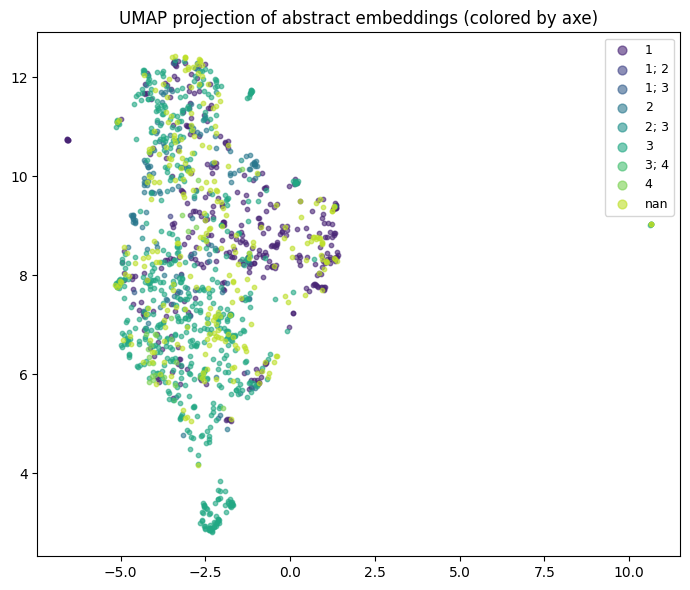

In [ ]:
import matplotlib.pyplot as plt
df_nz['axe']=df_nz['axe'].fillna("nan")
labels = df_nz["axe"].values
print(labels)
unique_labels = sorted(set(labels))

cmap = plt.cm.viridis
colors = cmap(np.linspace(0.1, 0.9, len(unique_labels)))

color_map = dict(zip(unique_labels, colors))

#----------------plot------------------------
plt.figure(figsize=(7,6))
for lab in unique_labels:
    idx = labels == lab
    plt.scatter(
        X_2d[idx, 0],
        X_2d[idx, 1],
        label=lab,
        alpha=0.6,
        s=10,
        color=color_map[lab]
    )

plt.legend(markerscale=2, fontsize=9)
plt.title("UMAP projection des embeddings du résumé")
plt.tight_layout()
plt.show()
